# SFWM Project

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import hamhelper.plotting as hp
import hamhelper.colours as hc
from tabulate import tabulate

## User Configuration

In [45]:
# Constants
c= 2.9979e8  # Speed of light in m/s

# User params
wl_pump  =   1310.0 * 1e-9  # pump wavelength in meters
fsr_targ =      0.5 * 1e-9   # Target FSR in nm
wl_sim_range = 10.0 * 1e-9  # Wavelength range for simulation in nm
dc_coupling = 0.98

# Simulated params
n_eff  = 1.9
dn_dwl = 0.1 * 1e-9  # nm
beta2  = -5.0e-26  # Generic
atten_dBcm = 0.8
A_eff = 1.0e-12  # Effective mode area in m^2
n2 = 2.4e-19  # m^2/W - Generic

# Derived parameters
n_g = n_eff - wl_pump * dn_dwl
v_g = c / n_g

# Print pretty table using tabulate

## FSR and Ring Sizing

In [46]:
# Estimate geometry from target
L_est = wl_pump**2 / (n_g * fsr_targ)  # In nm
m_est= n_eff * L_est / wl_pump
m_est_rounded = round(m_est)

# Match L exactly to rounded mode number
L_0 = m_est_rounded * wl_pump / n_eff
R_0 = L_0 / (2 * np.pi)

# Calculate FSR
D1 = 2 * np.pi * v_g / L_0
fsr_0_nm = wl_pump**2 * D1 / (2 * np.pi * c)

print(f"Resonant Mode (m): {m_est_rounded} | Exact Radius: {R_0*1e6:.2f} um -> FSR: {fsr_0_nm*1e9:.2f} nm")

Resonant Mode (m): 2620 | Exact Radius: 287.50 um -> FSR: 0.50 nm


In [50]:
# Convert to frequency omega
omega_pump = 2 * np.pi * c / wl_pump
omega_range = wl_sim_range * 2 * np.pi * c / (wl_pump**2)  # Convert wavelength range to frequency range
omega_range = 1.5 * D1

# Generate frequency grid
omega_arr = np.linspace(omega_pump - omega_range, omega_pump + omega_range, 20000)
wl_arr = 2 * np.pi * c / omega_arr

# Reconstruct dispersion-aware propagation constant beta(omega)
beta0 = omega_pump * n_eff / c
beta1 = 1.0 / v_g
beta_arr = beta0 + beta1 * (omega_arr - omega_pump) + 0.5 * beta2 * (omega_arr - omega_pump)**2

# Round-trip phase calculation
theta_arr = beta_arr * L_0

In [ ]:
# --- BLOCK 4: COUPLING & INTENSITY DYNAMICS ---
atten_dB_m = atten_dBcm * 100
loss_roundtrip = atten_dB_m * L_0
a = 10**(-loss_roundtrip / 20) # Internal amplitude round-trip transmission

# Define transmission coupling coefficient (t)
t = dc_coupling * a

# Transmission & Field Enhancement Profiles
transmission_thru = (t - a * np.exp(-1j * theta_arr)) / (1 - a * t * np.exp(-1j * theta_arr))
thru_dB = 10 * np.log10(np.abs(transmission_thru)**2)

kappa = np.sqrt(1 - t**2)
fe_amplitude = np.abs(kappa / (1 - a * t * np.exp(-1j * theta_arr)))
power_buildup = fe_amplitude**2
fe_peak = kappa / (1 - a * t)



Integrated Dispersion D_int: 0.19 MHz
Intracavity Power Needed for Phase Matching: 0.003 W
Required Input Bus Waveguide Power         : 0.12 mW


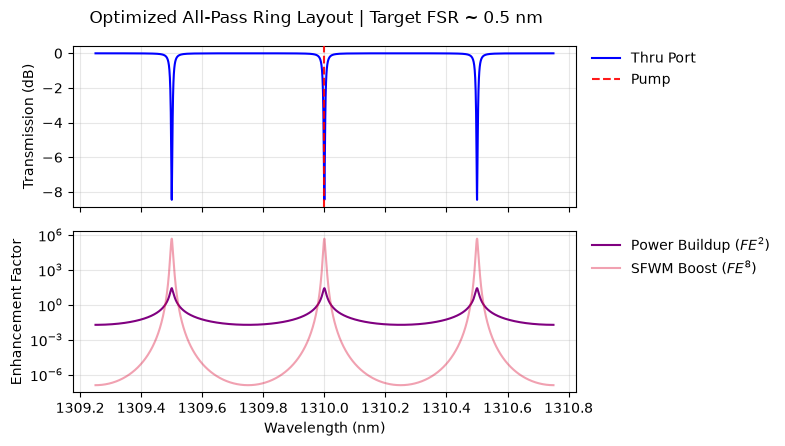

In [60]:
# SFWM and Dispersion Analysis
# D2 calculation: FSR change rate per mode step
D2 = - v_g * beta2 * (D1**2)
D_int_mu1 = 0.5 * D2 * (1**2) # Mismatch at 1st sideband pair (rad/s)

# Nonlinear power
gamma_nl =2 * np.pi * n2 / (wl_pump * A_eff)  # Nonlinear coefficient (1/W/m)
req_p_intra = D_int_mu1 / (2 * v_g * gamma_nl) if D2 > 0 else 0
req_p_bus = req_p_intra / (fe_peak**2) if D2 > 0 else 0

# Print final diagnostic log
print("\n" + "="*80)
print(f"Integrated Dispersion D_int: {D_int_mu1 / (2 * np.pi * 1e6):.2f} MHz")
print(f"Intracavity Power Needed for Phase Matching: {req_p_intra:.3f} W")
print(f"Required Input Bus Waveguide Power         : {req_p_bus*1e3:.2f} mW")
print("="*80)

# Build Verification Graphics
fig, (ax_thru, ax_fe) = plt.subplots(2, 1, figsize=(6.5, 4.5), sharex=True)
fig.subplots_adjust(hspace=0.15)

# Thru Transmission
ax_thru.plot(wl_arr * 1e9, thru_dB, color='blue', label='Thru Port')
ax_thru.axvline(x=wl_pump * 1e9, color='red', linestyle='--', alpha=0.9, label='Pump', zorder=100)
ax_thru.set_ylabel('Transmission (dB)')
ax_thru.grid(True, alpha=0.3)
ax_thru.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0., framealpha=0)

# Field Enhancement Scaling Profiles
ax_fe.plot(wl_arr * 1e9, power_buildup, color='purple', label='Power Buildup ($FE^2$)')
ax_fe.plot(wl_arr * 1e9, fe_amplitude**8, color='crimson', alpha=0.4, label='SFWM Boost ($FE^8$)')
ax_fe.set_ylabel('Enhancement Factor')
ax_fe.set_xlabel('Wavelength (nm)')
ax_fe.set_yscale('log')
ax_fe.grid(True, alpha=0.3)
ax_fe.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0., framealpha=0)

plt.suptitle(f'Optimized All-Pass Ring Layout | Target FSR ~ {fsr_targ*1e9:.1f} nm', y=0.96)
plt.show()
